Courant number: 0.00455


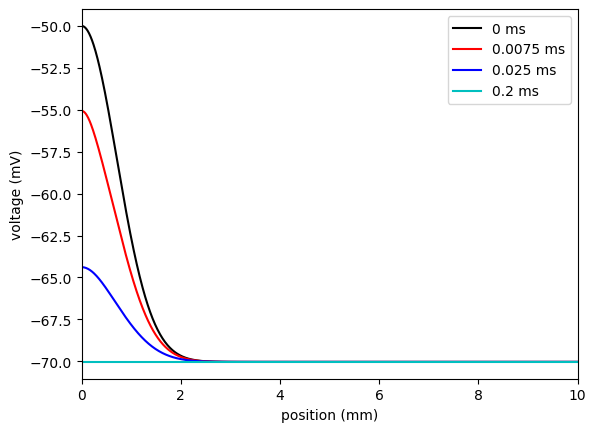

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Initialize parameters
V0 = -50      # Height of the initial voltage pulse (subthreshold)
Sigma = 1     # Width of the initial voltage pulse
tau = 2
lambda_ = 9.1 / 50
VNa = 54      # Na Nernst voltage
VK = -75      # K Nernst voltage
gNa = 1 / 5   # Na conductivity when the channels are inactivated
gK = 5        # K conductivity
betaq = 0.5   # beta*q from eqn. 17.29
Vthresh = -40 # Threshold value V* from eqn. 17.29
L = 10        # Length over which we will integrate
dx = 0.01     # Size of our circuit elements
t = 30        # Total integration time
dt = 0.0005   # Time step for the integration
Vmem = (VNa * gNa + VK * gK) / (gNa + gK)  # Steady state membrane potential
SavePeriod = 100  # How often we want to save the results

# Domain of integration
xRange = np.arange(-L + dx, L, dx)
tRange = np.arange(0, t + dt, dt)

# Initialize voltage array V
V = np.zeros((len(xRange), 2))  # 2 columns for previous and current voltage
V[:, 0] = (V0 - Vmem) * np.exp(-((xRange) / Sigma) ** 2) + Vmem
Vout = np.copy(V)  # To store the results
tout = tRange[0]

# Save results every SavePeriod iterations
SaveCounter = 0

# Time-stepping loop
for i in range(1, len(tRange)):
    # Calculate sodium conductivity
    gNaFunc = (100 / (1 + np.exp(betaq * (Vthresh - V[:, 0]))) + gNa)
    
    # Update voltage at the boundary (x = 0)
    V[0, 1] = V[0, 0] + dt / tau * (lambda_ ** 2 / dx ** 2 * (V[1, 0] - 2 * V[0, 0] + V[-1, 0]) 
                                    - gNaFunc[0] / gK * (V[0, 0] - VNa) - (V[0, 0] - VK))
    
    # Update voltage for the middle circuit elements
    for j in range(1, len(V[:, 0]) - 1):
        V[j, 1] = V[j, 0] + dt / tau * (lambda_ ** 2 / dx ** 2 * (V[j + 1, 0] - 2 * V[j, 0] + V[j - 1, 0]) 
                                       - gNaFunc[j] / gK * (V[j, 0] - VNa) - (V[j, 0] - VK))
    
    # Update voltage at the last element (x = L)
    V[-1, 1] = V[-1, 0] + dt / tau * (lambda_ ** 2 / dx ** 2 * (V[0, 0] - 2 * V[-1, 0] + V[-2, 0]) 
                                      - gNaFunc[-1] / gK * (V[-1, 0] - VNa) - (V[-1, 0] - VK))
    
    # Save the voltage profile at specified intervals
    if SaveCounter == SavePeriod:
        Vout = np.column_stack((Vout, V[:, 1]))
        SaveCounter = 0
    
    SaveCounter += 1
    
    # Update voltage for next iteration
    V[:, 0] = V[:, 1]
    V[:, 1] = 0  # Reset current voltage

# Plot the results
plt.plot(xRange, Vout[:, 0], '-k', label='0 ms')
plt.plot(xRange, Vout[:, 15], '-r', label='0.0075 ms')
plt.plot(xRange, Vout[:, 50], '-b', label='0.025 ms')
#plt.plot(xRange, Vout[:, 300], '-g', label='300')
plt.plot(xRange, Vout[:, 400], '-c', label='0.2 ms')
#plt.plot(xRange, Vout[:, 500], '-k', label='500')
#plt.plot(xRange, Vout[:, 600], '--r', label='600')
plt.xlabel('position (mm)')
plt.ylabel('voltage (mV)')
plt.xlim([0, L])
plt.legend()
plt.show()

In [ ]:
# Vectorization implementation

# Initialize parameters
V0 = -50      # Height of the initial voltage pulse (subthreshold)
Sigma = 1     # Width of the initial voltage pulse
tau = 2
lambda_ = 9.1 / 50
VNa = 54      # Na Nernst voltage
VK = -75      # K Nernst voltage
gNa = 1 / 5   # Na conductivity when the channels are inactivated
gK = 5        # K conductivity
betaq = 0.5   # beta*q from eqn. 17.29
Vthresh = -40 # Threshold value V* from eqn. 17.29
L = 10        # Length over which we will integrate
dx = 0.01     # Size of our circuit elements
t = 30        # Total integration time
dt = 0.0005   # Time step for the integration
Vmem = (VNa * gNa + VK * gK) / (gNa + gK)  # Steady state membrane potential
SavePeriod = 100  # How often we want to save the results

# Domain of integration
xRange = np.arange(-L + dx, L, dx)
tRange = np.arange(0, t + dt, dt)

# Initialize voltage array V
V = np.zeros((len(xRange), 2))  # 2 columns for previous and current voltage
V[:, 0] = (V0 - Vmem) * np.exp(-((xRange) / Sigma) ** 2) + Vmem
Vout = np.copy(V)  # To store the results
tout = tRange[0]

# Save results every SavePeriod iterations
SaveCounter = 0

# Time-stepping loop
for i in range(1, len(tRange)):
    # Calculate sodium conductivity for all points at once
    gNaFunc = (100 / (1 + np.exp(betaq * (Vthresh - V[:, 0]))) + gNa)
    
    # Compute the second derivative (laplacian) of V
    d2V = np.zeros_like(V[:, 0])
    d2V[1:-1] = (V[2:, 0] - 2 * V[1:-1, 0] + V[:-2, 0]) / dx**2  # Central difference
    # Boundary conditions for second derivative (can be adjusted as needed)
    d2V[0] = (V[1, 0] - V[0, 0]) / dx**2  # Assuming forward difference for left boundary
    d2V[-1] = (V[-1, 0] - V[-2, 0]) / dx**2  # Assuming backward difference for right boundary

    # Voltage update (all points at once)
    dV = dt / tau * (lambda_**2 * d2V - gNaFunc / gK * (V[:, 0] - VNa) - (V[:, 0] - VK))
    
    # Update the voltage
    V[:, 1] = V[:, 0] + dV

    # Save the voltage profile at specified intervals
    if SaveCounter == SavePeriod:
        Vout = np.column_stack((Vout, V[:, 1]))
        SaveCounter = 0
    
    SaveCounter += 1
    
    # Update voltage for next iteration
    V[:, 0] = V[:, 1]
    V[:, 1] = 0  # Reset current voltage

# Plot the results
plt.plot(xRange, Vout[:, 0], '-k', label='0 ms')
plt.plot(xRange, Vout[:, 15], '-r', label='0.0075 ms')
plt.plot(xRange, Vout[:, 50], '-b', label='0.025 ms')
#plt.plot(xRange, Vout[:, 300], '-g', label='300')
plt.plot(xRange, Vout[:, 400], '-c', label='0.2 ms')
#plt.plot(xRange, Vout[:, 500], '-k', label='500')
#plt.plot(xRange, Vout[:, 600], '--r', label='600')
plt.xlabel('position (mm)')
plt.ylabel('voltage (mV)')
plt.xlim([0, L])
plt.legend()
plt.show()

Courant number: 0.00455


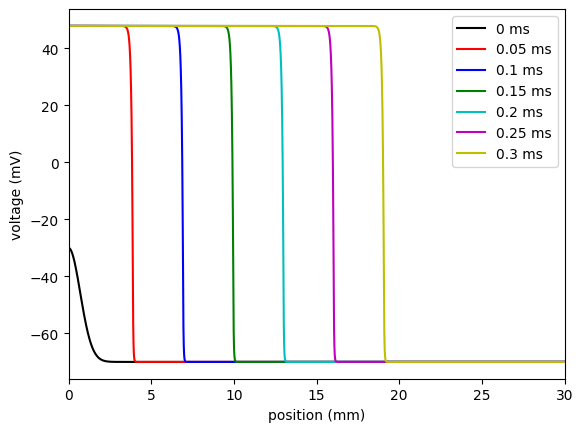

In [ ]:
# Initialize parameters
V0 = -30      # Height of the initial voltage pulse (above threshold)
Sigma = 1     # Width of the initial voltage pulse
tau = 2
lambda_ = 9.1 / 50
VNa = 54      # Na Nernst voltage
VK = -75      # K Nernst voltage
gNa = 1 / 5   # Na conductivity when the channels are inactivated
gK = 5        # K conductivity
betaq = 0.5   # beta*q from eqn. 17.29
Vthresh = -40 # Threshold value V* from eqn. 17.29
L = 30        # Length over which we will integrate
dx = 0.01     # Size of our circuit elements
t = 30        # Total integration time
dt = 0.0005   # Time step for the integration
Vmem = (VNa * gNa + VK * gK) / (gNa + gK)  # Steady state membrane potential
SavePeriod = 100  # How often we want to save the results

# Domain of integration
xRange = np.arange(-L + dx, L, dx)
tRange = np.arange(0, t + dt, dt)

# Courant number (check stability)
CourantNumber = lambda_ / tau * dt / dx
print(f"Courant number: {CourantNumber}")

# Initialize voltage array V
V = np.zeros((len(xRange), 2))  # 2 columns for previous and current voltage
V[:, 0] = (V0 - Vmem) * np.exp(-((xRange) / Sigma) ** 2) + Vmem
Vout = np.copy(V)  # To store the results
tout = tRange[0]

# Save results every SavePeriod iterations
SaveCounter = 0

# Time-stepping loop
for i in range(1, len(tRange)):
    # Calculate sodium conductivity
    gNaFunc = (100 / (1 + np.exp(betaq * (Vthresh - V[:, 0]))) + gNa)
    
    # Update voltage at the boundary (x = 0)
    V[0, 1] = V[0, 0] + dt / tau * (lambda_ ** 2 / dx ** 2 * (V[1, 0] - 2 * V[0, 0] + V[-1, 0]) 
                                    - gNaFunc[0] / gK * (V[0, 0] - VNa) - (V[0, 0] - VK))
    
    # Update voltage for the middle circuit elements
    for j in range(1, len(V[:, 0]) - 1):
        V[j, 1] = V[j, 0] + dt / tau * (lambda_ ** 2 / dx ** 2 * (V[j + 1, 0] - 2 * V[j, 0] + V[j - 1, 0]) 
                                       - gNaFunc[j] / gK * (V[j, 0] - VNa) - (V[j, 0] - VK))
    
    # Update voltage at the last element (x = L)
    V[-1, 1] = V[-1, 0] + dt / tau * (lambda_ ** 2 / dx ** 2 * (V[0, 0] - 2 * V[-1, 0] + V[-2, 0]) 
                                      - gNaFunc[-1] / gK * (V[-1, 0] - VNa) - (V[-1, 0] - VK))
    
    # Save the voltage profile at specified intervals
    if SaveCounter == SavePeriod:
        Vout = np.column_stack((Vout, V[:, 1]))
        SaveCounter = 0
    
    SaveCounter += 1
    
    # Update voltage for next iteration
    V[:, 0] = V[:, 1]
    V[:, 1] = 0  # Reset current voltage

# Plot the results
plt.plot(xRange, Vout[:, 0], '-k', label='0 ms')
plt.plot(xRange, Vout[:, 100], '-r', label='0.05 ms')
plt.plot(xRange, Vout[:, 200], '-b', label='0.1 ms')
plt.plot(xRange, Vout[:, 300], '-g', label='0.15 ms')
plt.plot(xRange, Vout[:, 400], '-c', label='0.2 ms')
plt.plot(xRange, Vout[:, 500], '-m', label='0.25 ms')
plt.plot(xRange, Vout[:, 600], '-y', label='0.3 ms')
plt.xlabel('position (mm)')
plt.ylabel('voltage (mV)')
plt.xlim([0, L])
plt.legend()
plt.show()

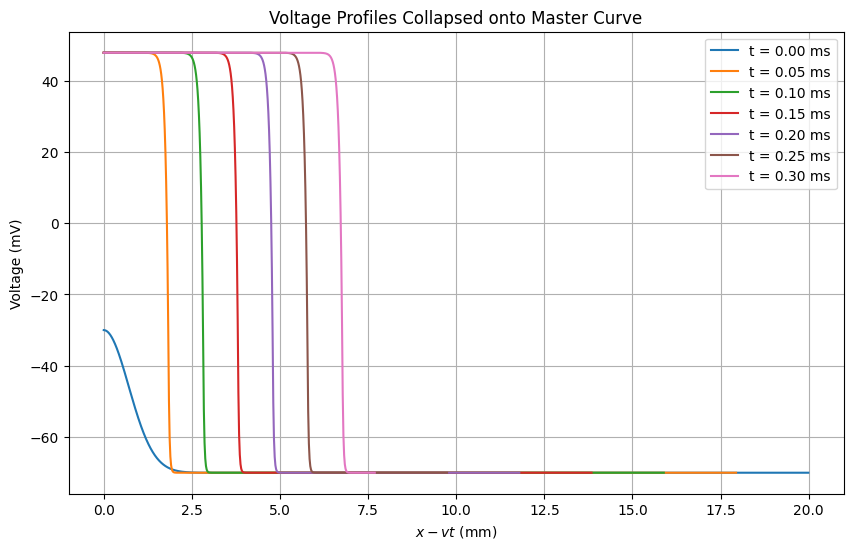

In [ ]:
# Initialize parameters (same as before)
V0 = -30      # Initial voltage pulse (above threshold)
Sigma = 1     # Width of the initial voltage pulse
tau = 2
lambda_ = 9.1 / 50
VNa = 54      # Na Nernst voltage
VK = -75      # K Nernst voltage
gNa = 1 / 5   # Na conductivity when the channels are inactivated
gK = 5        # K conductivity
betaq = 0.5   # beta*q from eqn. 17.29
Vthresh = -40 # Threshold value V* from eqn. 17.29
L = 20        # Length of the cable
dx = 0.01     # Size of our circuit elements
t = 30        # Total integration time
dt = 0.0005   # Time step for the integration
Vmem = (VNa * gNa + VK * gK) / (gNa + gK)  # Steady state membrane potential
SavePeriod = 100  # How often we want to save the results

# Domain of integration
xRange = np.arange(-L + dx, L, dx)  # Update for new L value
tRange = np.arange(0, t + dt, dt)

# Initialize voltage array V
V = np.zeros((len(xRange), 2))  # 2 columns for previous and current voltage
V[:, 0] = (V0 - Vmem) * np.exp(-((xRange) / Sigma) ** 2) + Vmem
Vout = np.copy(V)  # To store the results

# Save results every SavePeriod iterations
SaveCounter = 0

# Time-stepping loop
for i in range(1, len(tRange)):
    # Calculate sodium conductivity
    gNaFunc = (100 / (1 + np.exp(betaq * (Vthresh - V[:, 0]))) + gNa)
    
    # Update voltage at the boundary (x = 0)
    V[0, 1] = V[0, 0] + dt / tau * (lambda_ ** 2 / dx ** 2 * (V[1, 0] - 2 * V[0, 0] + V[-1, 0]) 
                                    - gNaFunc[0] / gK * (V[0, 0] - VNa) - (V[0, 0] - VK))
    
    # Update voltage for the middle circuit elements
    for j in range(1, len(V[:, 0]) - 1):
        V[j, 1] = V[j, 0] + dt / tau * (lambda_ ** 2 / dx ** 2 * (V[j + 1, 0] - 2 * V[j, 0] + V[j - 1, 0]) 
                                       - gNaFunc[j] / gK * (V[j, 0] - VNa) - (V[j, 0] - VK))
    
    # Update voltage at the last element (x = L)
    V[-1, 1] = V[-1, 0] + dt / tau * (lambda_ ** 2 / dx ** 2 * (V[0, 0] - 2 * V[-1, 0] + V[-2, 0]) 
                                      - gNaFunc[-1] / gK * (V[-1, 0] - VNa) - (V[-1, 0] - VK))
    
    # Save the voltage profile at specified intervals
    if SaveCounter == SavePeriod:
        Vout = np.column_stack((Vout, V[:, 1]))
        SaveCounter = 0
    
    SaveCounter += 1
    
    # Update voltage for next iteration
    V[:, 0] = V[:, 1]
    V[:, 1] = 0  # Reset current voltage

# Choose an approximate propagation speed v (this will be refined)
v = 41  # Guess an initial speed (mm/ms)

# Plot the collapsed profiles by transforming x -> x - vt
plt.figure(figsize=(10, 6))

# Loop through each time step and collapse the profiles
for i in range(0, Vout.shape[1], SavePeriod):
    x_prime = xRange - v * tRange[i]  # Transform the x-coordinate
    # Select only the portion where x_prime > 0
    mask = x_prime > 0
    plt.plot(x_prime[mask], Vout[mask, i], label=f't = {tRange[i]:.2f} ms')

# Add labels and legend
plt.xlabel('$x-vt$ (mm)')
plt.ylabel('Voltage (mV)')
plt.title('Voltage Profiles Collapsed onto Master Curve')
plt.legend(loc='best')
plt.grid(True)
plt.show()